# Data Analytics - Association Rule Learning

In [1]:
import csv
import time
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

## Функции программы

In [2]:
def load_dataset_from_csv(filename, delimiter=','):
    """
    Загружает данные из CSV-файла.

    Параметры:
        filename: путь к CSV-файлу;
        delimiter: разделитель (по умолчанию запятая).

    Возвращает:
        Список транзакций, где каждая транзакция представлена списком объектов.
    """
    dataset = []
    with open(filename, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter=delimiter)
        for row in reader:
            # Убираем лишние пробелы и пустые элементы
            transaction = [item.strip() for item in row if item.strip()]
            if transaction:
                dataset.append(transaction)
    return dataset

def apriori(dataset, min_support, sort_method="support"):
    """
    Поиск частых наборов объектов с помощью алгоритма Apriori.

    Параметры:
        dataset: список транзакций (каждая транзакция – список объектов);
        min_support: порог поддержки; если значение меньше 1, трактуется как относительная поддержка;
        sort_method: способ упорядочивания результата:
                     "support" – по убыванию поддержки,
                     "lex" – лексикографически.

    Возвращает:
        Кортеж:
          - freq_itemsets: словарь {frozenset(набор): поддержка},
          - result: список кортежей (набор, поддержка) для удобного вывода.
    """
    total_transactions = len(dataset)
    # Абсолютный порог поддержки
    absolute_threshold = min_support * total_transactions if min_support < 1 else min_support

    freq_itemsets = {}
    item_counts = defaultdict(int)

    # Шаг 1: Частотные 1-элементные наборы.
    for transaction in dataset:
        for item in transaction:
            item_counts[item] += 1
    L1 = []
    for item, count in item_counts.items():
        if count >= absolute_threshold:
            itemset = frozenset([item])
            L1.append(itemset)
            freq_itemsets[itemset] = count / total_transactions

    # Шаг 2: Итеративное построение наборов большей длины.
    current_L = L1
    k = 2
    while current_L:
        candidates = generate_candidates(current_L, k)
        candidate_counts = defaultdict(int)
        for transaction in dataset:
            transaction_set = set(transaction)
            for candidate in candidates:
                if candidate.issubset(transaction_set):
                    candidate_counts[candidate] += 1
        current_L = []
        for candidate, count in candidate_counts.items():
            if count >= absolute_threshold:
                current_L.append(candidate)
                freq_itemsets[candidate] = count / total_transactions
        k += 1

    # Формирование результирующего списка (для удобного отображения)
    result = [(set(itemset), support) for itemset, support in freq_itemsets.items()]
    if sort_method == "support":
        result = sorted(result, key=lambda x: x[1], reverse=True)
    elif sort_method == "lex":
        result = sorted(result, key=lambda x: tuple(sorted(x[0])))
    return freq_itemsets, result

def generate_candidates(prev_frequent, k):
    """
    Генерация кандидатов для наборов длины k на основе предыдущего набора частотных (k-1)-элементных наборов.
    """
    candidates = []
    prev_frequent_list = list(prev_frequent)
    len_prev = len(prev_frequent_list)
    for i in range(len_prev):
        for j in range(i + 1, len_prev):
            l1 = sorted(list(prev_frequent_list[i]))
            l2 = sorted(list(prev_frequent_list[j]))
            # Объединяем наборы, если первые k-2 элементов совпадают
            if l1[:k-2] == l2[:k-2]:
                candidate = prev_frequent_list[i] | prev_frequent_list[j]
                if not has_infrequent_subset(candidate, prev_frequent):
                    candidates.append(candidate)
    return candidates

def has_infrequent_subset(candidate, prev_frequent):
    """
    Проверяет, что все (k-1)-подмножества кандидата присутствуют в предыдущем наборе частотных наборов.
    Если хотя бы один поднабор отсутствует, возвращается True.
    """
    candidate_list = list(candidate)
    for subset in combinations(candidate_list, len(candidate) - 1):
        if frozenset(subset) not in prev_frequent:
            return True
    return False

def generate_association_rules(freq_itemsets, min_confidence, sort_method="support"):
    """
    Генерация ассоциативных правил на основе найденных частых наборов.

    Параметры:
        freq_itemsets: словарь {frozenset(набор): поддержка};
        min_confidence: минимальный порог достоверности;
        sort_method: способ сортировки результата:
                     "support" – по убыванию поддержки,
                     "lex" – лексикографически.

    Возвращает:
        Список правил в виде кортежей:
            (antecedent, consequent, support, confidence)
    """
    rules = []
    for itemset in freq_itemsets:
        if len(itemset) < 2:
            continue
        # Для каждого непустого собственного подмножества
        for i in range(1, len(itemset)):
            for antecedent in combinations(itemset, i):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                if not consequent:
                    continue
                if antecedent in freq_itemsets:
                    confidence = freq_itemsets[itemset] / freq_itemsets[antecedent]
                    if confidence >= min_confidence:
                        rules.append((set(antecedent), set(consequent), freq_itemsets[itemset], confidence))
    if sort_method == "support":
        rules = sorted(rules, key=lambda x: x[2], reverse=True)
    elif sort_method == "lex":
        rules = sorted(rules, key=lambda x: (tuple(sorted(x[0])), tuple(sorted(x[1]))))
    return rules

## Применение алгоритма

In [24]:
# Загрузка данных из файла baskets.csv (файл должен находиться в рабочей директории)
csv_filename = "baskets.csv"
dataset = load_dataset_from_csv(csv_filename, delimiter=',')

# Задаём список пороговых значений поддержки для эксперимента
support_thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]
# Порог достоверности для ассоциативных правил
min_confidence = 0.2  # например, 50%
# Метод сортировки для частых наборов и правил: "support" или "lex"
sort_method = "support"  # можно изменить на "lex"

# Словари для хранения времени выполнения и статистики по наборам для каждого порога поддержки
runtimes = {}
itemset_counts = {}  # ключ: порог поддержки, значение: словарь {длина набора: количество}
rules_counts = {}    # для каждого порога — количество правил

# Эксперимент: варьируем порог поддержки
for support in support_thresholds:
    print(f"\nЗапуск алгоритма Apriori с порогом поддержки {support:.0%}")
    start_time = time.time()
    freq_itemsets, frequent_itemsets_list = apriori(dataset, support, sort_method=sort_method)
    elapsed_time = time.time() - start_time
    runtimes[support] = elapsed_time

    # Подсчёт количества частых наборов по длине
    length_count = {}
    for itemset, supp in frequent_itemsets_list:
        length = len(itemset)
        length_count[length] = length_count.get(length, 0) + 1
    itemset_counts[support] = length_count

    # Генерация ассоциативных правил для данного порога поддержки
    rules = generate_association_rules(freq_itemsets, min_confidence, sort_method=sort_method)
    rules_counts[support] = len(rules)

    print(f"  Время выполнения: {elapsed_time:.4f} сек, Найдено наборов: {len(frequent_itemsets_list)}, Найдено правил: {len(rules)}")



Запуск алгоритма Apriori с порогом поддержки 1%
  Время выполнения: 1.1711 сек, Найдено наборов: 261, Найдено правил: 163

Запуск алгоритма Apriori с порогом поддержки 3%
  Время выполнения: 0.2540 сек, Найдено наборов: 55, Найдено правил: 26

Запуск алгоритма Apriori с порогом поддержки 5%
  Время выполнения: 0.1293 сек, Найдено наборов: 28, Найдено правил: 6

Запуск алгоритма Apriori с порогом поддержки 10%
  Время выполнения: 0.0157 сек, Найдено наборов: 7, Найдено правил: 0

Запуск алгоритма Apriori с порогом поддержки 15%
  Время выполнения: 0.0111 сек, Найдено наборов: 5, Найдено правил: 0


## Визуализация

#### Сравнение быстродействия поиска правил при изменении порога достоверности.

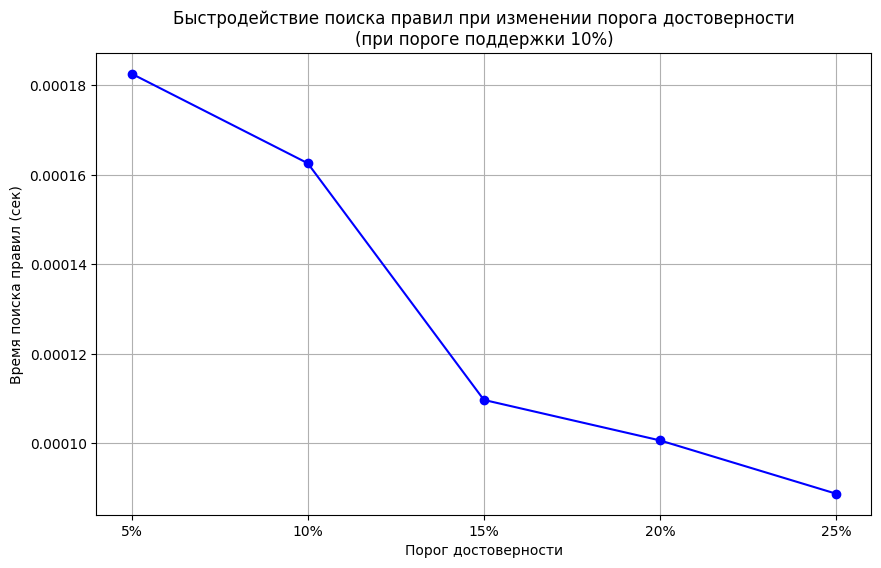

In [25]:
plt.figure(figsize=(10, 6))
x_values = conf_thresholds
y_runtime = [runtime_rules[conf] for conf in conf_thresholds]
plt.plot(x_values, y_runtime, marker='o', linestyle='-', color='b')
plt.xlabel('Порог достоверности')
plt.ylabel('Время поиска правил (сек)')
plt.title('Быстродействие поиска правил при изменении порога достоверности\n(при пороге поддержки 10%)')
plt.grid(True)
plt.xticks(conf_thresholds, [f"{conf:.0%}" for conf in conf_thresholds])
plt.savefig('rules_runtime_vs_confidence.png')
plt.show()

#### Общее количество найденных правил при изменении порога достоверности.

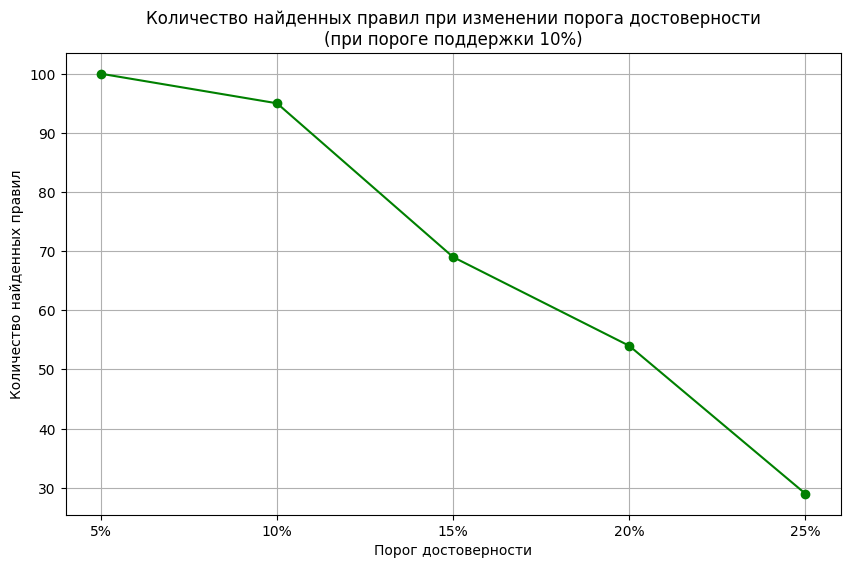

In [26]:
plt.figure(figsize=(10, 6))
y_rule_counts = [rule_counts[conf] for conf in conf_thresholds]
plt.plot(x_values, y_rule_counts, marker='o', linestyle='-', color='g')
plt.xlabel('Порог достоверности')
plt.ylabel('Количество найденных правил')
plt.title('Количество найденных правил при изменении порога достоверности\n(при пороге поддержки 10%)')
plt.grid(True)
plt.xticks(conf_thresholds, [f"{conf:.0%}" for conf in conf_thresholds])
plt.savefig('rules_count_vs_confidence.png')
plt.show()

## Вывод ассоциативных правил в читаемом виде для выбранного порога поддержки


In [27]:
target_support = 0.05  # выбираем порог, для которого детально выведем правила
print(f"\nАссоциативные правила для порога поддержки {target_support:.0%} и порога достоверности {min_confidence:.0%}:")
freq_itemsets_target, frequent_itemsets_target = apriori(dataset, target_support, sort_method=sort_method)
rules = generate_association_rules(freq_itemsets_target, min_confidence, sort_method=sort_method)
if rules:
    for antecedent, consequent, support_value, confidence in rules:
        antecedent_str = ", ".join(sorted(antecedent))
        consequent_str = ", ".join(sorted(consequent))
        print(f"  {antecedent_str} -> {consequent_str} | Поддержка: {support_value:.2f}, Достоверность: {confidence:.2f}")
else:
    print("  Нет правил, удовлетворяющих заданным порогам.")


Ассоциативные правила для порога поддержки 5% и порога достоверности 20%:
  макароны -> минеральная вода | Поддержка: 0.06, Достоверность: 0.32
  минеральная вода -> макароны | Поддержка: 0.06, Достоверность: 0.26
  шоколад -> минеральная вода | Поддержка: 0.05, Достоверность: 0.32
  минеральная вода -> шоколад | Поддержка: 0.05, Достоверность: 0.22
  яйца -> минеральная вода | Поддержка: 0.05, Достоверность: 0.28
  минеральная вода -> яйца | Поддержка: 0.05, Достоверность: 0.21
